In [23]:
#Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [24]:
# Load the Anime Data
data = pd.read_csv('data/anime.csv')

In [25]:
# Data 
print("="*70)
print("BASIC DATASET INFORMATION")
print("="*70)
print(f"\nDataset Shape: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nColumns: {list(data.columns)}")
print(f"\nData Types:\n{data.dtypes}")
print(f"\nMemory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

BASIC DATASET INFORMATION

Dataset Shape: 12294 rows × 7 columns

Columns: ['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

Data Types:
anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

Memory Usage: 3.61 MB


In [26]:
rating_data = pd.read_csv('data/rating.csv')

In [27]:
# Data 
print("="*70)
print("BASIC RATING DATASET INFORMATION")
print("="*70)
print(f"\nDataset Shape: {rating_data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nColumns: {list(rating_data.columns)}")
print(f"\nData Types:\n{rating_data.dtypes}")
print(f"\nMemory Usage: {rating_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

BASIC RATING DATASET INFORMATION

Dataset Shape: 7813737 rows × 7 columns

Columns: ['user_id', 'anime_id', 'rating']

Data Types:
user_id     int64
anime_id    int64
rating      int64
dtype: object

Memory Usage: 178.84 MB


In [28]:
print("--- ANIME DATASET (data) Statistics ---")
anime_stats = data[['rating', 'members']].agg(['count', 'min', 'median'])
print(anime_stats)

--- ANIME DATASET (data) Statistics ---
          rating  members
count   12064.00  12294.0
min         1.67      5.0
median      6.57   1550.0


In [29]:
print("\n--- RATING DATASET (rating_data) Statistics ---")
rating_stats = rating_data['rating'].agg(['count', 'min', 'median'])
print(rating_stats)


--- RATING DATASET (rating_data) Statistics ---
count     7813737.0
min            -1.0
median          7.0
Name: rating, dtype: float64


In [30]:
print("Null Values: ")
print("Anime dataset null values : ", data.isnull().sum())
print("Rating dataset null values : ", rating_data.isnull().sum())

Null Values: 
Anime dataset null values :  anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64
Rating dataset null values :  user_id     0
anime_id    0
rating      0
dtype: int64


In [31]:
data = data.dropna()
data.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [32]:
# Merging both dataset
merged_df = pd.merge(
    rating_data,        # Left DataFrame (the one you want to keep all rows from)
    data,         # Right DataFrame
    on='anime_id',    # The common column to merge on
    how='inner'       # Only keep rows where 'anime_id' exists in BOTH datasets
)

print("--- Merge Status ---")
print(f"Original rating_data shape: {rating_data.shape}")
print(f"Original data shape: {data.shape}")
print(f"Merged DataFrame shape: {merged_df.shape}")
print("\nMerged DataFrame Columns:")
print(merged_df.columns.tolist())

--- Merge Status ---
Original rating_data shape: (7813737, 3)
Original data shape: (12017, 7)
Merged DataFrame shape: (7813611, 9)

Merged DataFrame Columns:
['user_id', 'anime_id', 'rating_x', 'name', 'genre', 'type', 'episodes', 'rating_y', 'members']


In [33]:
# 1. Sort the DataFrame by the 'members' column in descending order
# and select the top 10 rows.
top_community_anime = data.sort_values(
    by='members',
    ascending=False
).head(10)

# 2. Select only the relevant columns for display
top_community_display = top_community_anime[['name', 'type', 'rating', 'members']]

# 3. Print the results
print("--- Top 10 Anime by Community Size ('members') ---")
print(top_community_display.to_markdown(index=False))

# Optional: Find the specific anime with the largest community
largest_community_anime = top_community_anime.iloc[0]

print("\n-------------------------------------------------")
print(f"The single anime with the largest community is:")
print(f"Name:    {largest_community_anime['name']}")
print(f"Members: {largest_community_anime['members']:,}") # Formats the number with commas
print(f"Type:    {largest_community_anime['type']}")
print(f"Rating:  {largest_community_anime['rating']}")

--- Top 10 Anime by Community Size ('members') ---
| name                             | type   |   rating |   members |
|:---------------------------------|:-------|---------:|----------:|
| Death Note                       | TV     |     8.71 |   1013917 |
| Shingeki no Kyojin               | TV     |     8.54 |    896229 |
| Sword Art Online                 | TV     |     7.83 |    893100 |
| Fullmetal Alchemist: Brotherhood | TV     |     9.26 |    793665 |
| Angel Beats!                     | TV     |     8.39 |    717796 |
| Code Geass: Hangyaku no Lelouch  | TV     |     8.83 |    715151 |
| Naruto                           | TV     |     7.81 |    683297 |
| Steins;Gate                      | TV     |     9.17 |    673572 |
| Mirai Nikki (TV)                 | TV     |     8.07 |    657190 |
| Toradora!                        | TV     |     8.45 |    633817 |

-------------------------------------------------
The single anime with the largest community is:
Name:    Death Note
Me

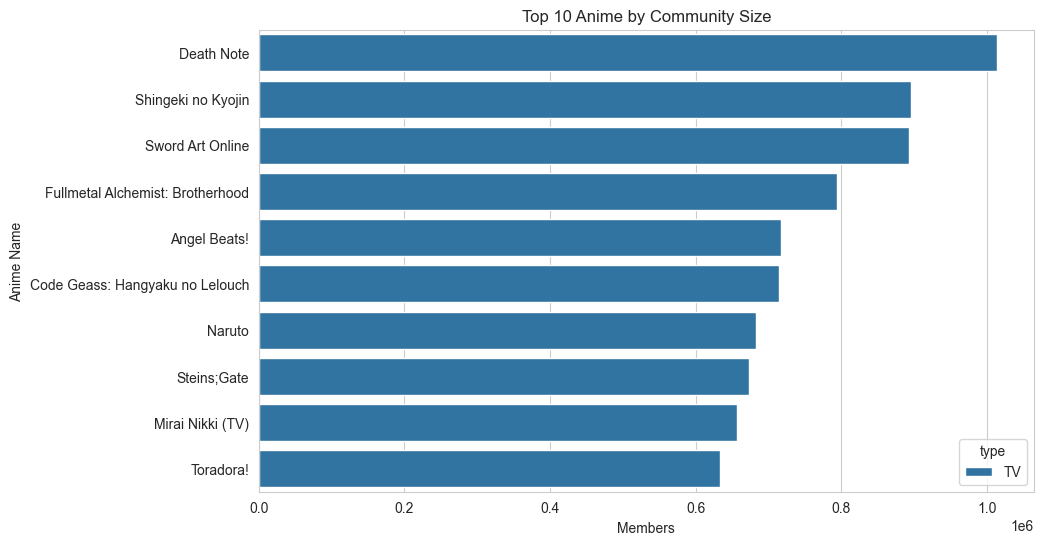

In [34]:
# 1. Select and Sort the Top 10 Anime
top_10 = data.sort_values(by='members', ascending=False).head(10)

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='members', 
    y='name', 
    data=top_10, 
    hue='type' # Still useful for differentiating TV series from movies
)
plt.title('Top 10 Anime by Community Size')
plt.xlabel('Members')
plt.ylabel('Anime Name')
plt.show() # Use plt.show() or plt.savefig() as needed

In [35]:
# Assuming your anime dataset is loaded as data

# 1. Handle Missing Ratings: Drop rows where the average rating is missing (NaN), 
# as these cannot be ranked.
data_clean = data.dropna(subset=['rating']).copy()

# 2. Sort the cleaned DataFrame by the 'rating' column in descending order
# and select the top 10 rows.
top_rated_anime = data_clean.sort_values(
    by='rating',
    ascending=False
).head(10)

# 3. Select and format the relevant columns for a clear display
top_rated_display = top_rated_anime[['name', 'type', 'episodes', 'rating', 'members']]

# 4. Print the results
print("--- Top 10 Anime Ranked by Average Community Rating ---")
print("Note: This ranking is based purely on the highest 'rating' score.")
print(top_rated_display.to_markdown(index=False, floatfmt=".2f"))

# Optional: Print the top-rated anime
highest_rated_anime = top_rated_anime.iloc[0]

print("\n---------------------------------------------------------")
print(f"The highest rated anime is:")
print(f"Name:    {highest_rated_anime['name']}")
print(f"Rating:  {highest_rated_anime['rating']:.2f}")
print(f"Members: {highest_rated_anime['members']:,}")

--- Top 10 Anime Ranked by Average Community Rating ---
Note: This ranking is based purely on the highest 'rating' score.
| name                                    | type   | episodes   |   rating |   members |
|:----------------------------------------|:-------|:-----------|---------:|----------:|
| Taka no Tsume 8: Yoshida-kun no X-Files | Movie  | 1          |    10.00 |        13 |
| Spoon-hime no Swing Kitchen             | TV     | Unknown    |     9.60 |        47 |
| Mogura no Motoro                        | Movie  | 1          |     9.50 |        62 |
| Kimi no Na wa.                          | Movie  | 1          |     9.37 |    200630 |
| Kahei no Umi                            | Movie  | 1          |     9.33 |        44 |
| Fullmetal Alchemist: Brotherhood        | TV     | 64         |     9.26 |    793665 |
| Yakusoku: Africa Mizu to Midori         | OVA    | 1          |     9.25 |        53 |
| Gintama°                                | TV     | 51         |     9.25 | 

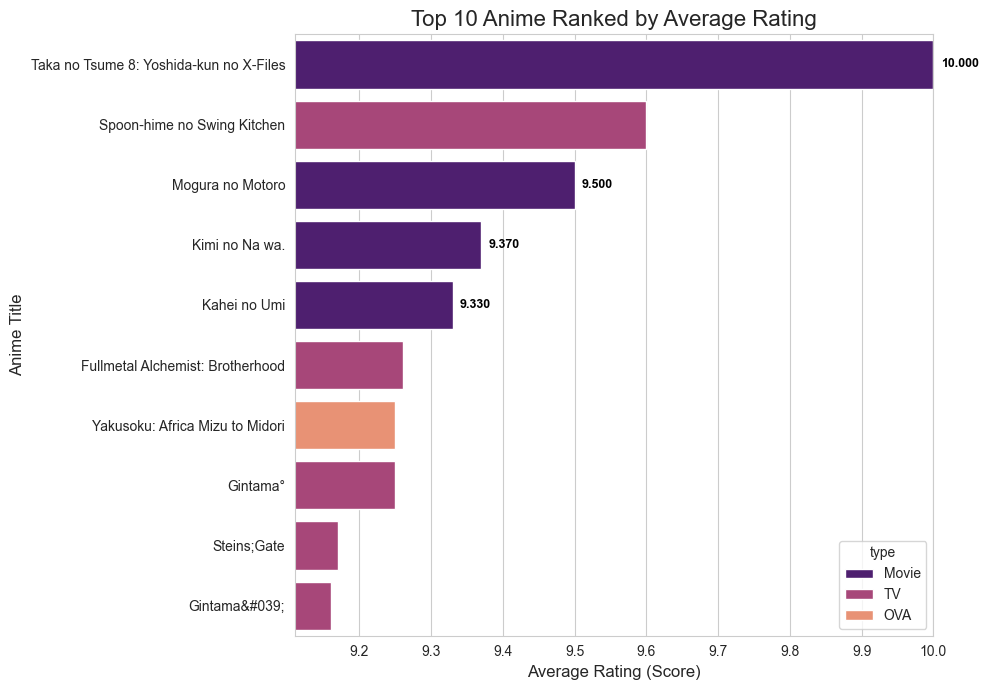

In [36]:
# Set up the plot aesthetics
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

# Create a horizontal bar chart
# x-axis is the 'rating' value, y-axis is the 'name' (categories)
# Use 'type' for coloring to see the format distribution (e.g., TV vs. Movie)
ax = sns.barplot(
    x='rating', 
    y='name', 
    data=top_rated_anime, 
    hue='type',
    dodge=False,
    palette='magma' # Use a different color palette for variety
)

# Customize the plot
plt.title('Top 10 Anime Ranked by Average Rating', fontsize=16)
plt.xlabel('Average Rating (Score)', fontsize=12)
plt.ylabel('Anime Title', fontsize=12)
plt.xlim(top_rated_anime['rating'].min() - 0.05, 10) # Set x-axis limit for better visual spread

# Add the rating value labels to the end of the bars for precision
for bar in ax.containers[0]:
    rating_value = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    ax.text(rating_value + 0.01, y_pos, f'{rating_value:.3f}', 
            ha='left', va='center', fontsize=9, color='black', weight='bold')

# Adjust layout
plt.tight_layout()
plt.show() # Use plt.show() or plt.savefig('top_10_rated_anime.png')

/var/folders/_h/_drprnqn0v9d76wx_s1kkysm0000gn/T/ipykernel_59194/1138551033.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=rating_data, ax=axes[1], palette='viridis', order=sorted(rating_data['rating'].unique()))


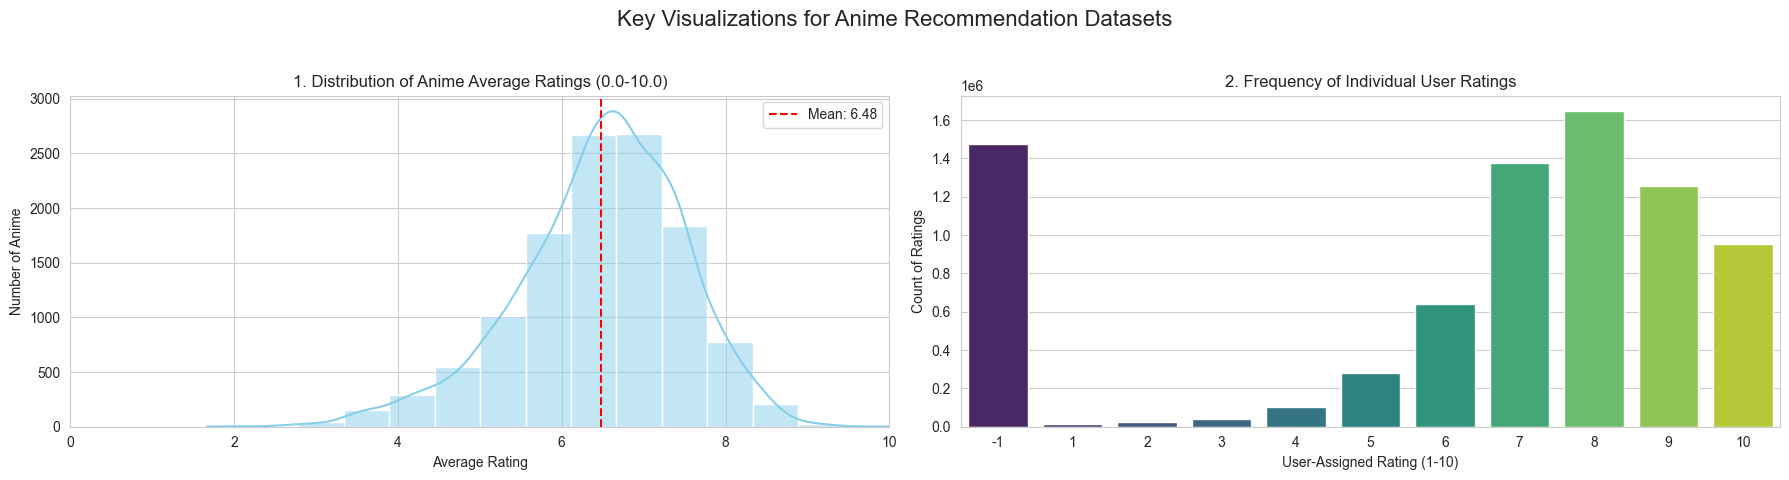

In [37]:
# Set the plotting style
sns.set_style("whitegrid")

# Create a figure with three subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Key Visualizations for Anime Recommendation Datasets', fontsize=16)

# --- 1. Distribution of Anime Average Ratings (data) ---
# Use .dropna() to ignore NaN values for the plot
sns.histplot(data['rating'].dropna(), kde=True, bins=15, ax=axes[0], color='skyblue')
axes[0].set_title('1. Distribution of Anime Average Ratings (0.0-10.0)', fontsize=12)
axes[0].set_xlabel('Average Rating', fontsize=10)
axes[0].set_ylabel('Number of Anime', fontsize=10)
axes[0].set_xlim(0, 10)
axes[0].axvline(data['rating'].mean(), color='red', linestyle='--', label=f"Mean: {data['rating'].mean():.2f}")
axes[0].legend()


# --- 2. Count Plot of Individual User Ratings (rating_data) ---
sns.countplot(x='rating', data=rating_data, ax=axes[1], palette='viridis', order=sorted(rating_data['rating'].unique()))
axes[1].set_title('2. Frequency of Individual User Ratings', fontsize=12)
axes[1].set_xlabel('User-Assigned Rating (1-10)', fontsize=10)
axes[1].set_ylabel('Count of Ratings', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('anime_data_visualizations.png')
# data.drop(columns=['log_members'], inplace=True, errors='ignore') # Cleanup

## Content Based Filtering

In [38]:
# 1. Data Cleaning and Vectorization
data['genre'] = data['genre'].fillna('')

# TF-IDF converts text (genres) into a numerical matrix, weighting rare genres higher.
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['genre'])

# 2. Similarity Calculation
# Calculate the cosine similarity matrix (pairwise similarity of every anime)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 3. Helper Series: Map anime name to its index
indices = pd.Series(data.index, index=data['name']).drop_duplicates()

# 4. Recommendation Function
def get_content_recommendations(title, cosine_sim=cosine_sim, df=data, indices=indices):
    """Generates the top 10 anime recommendations based on genre similarity."""
    
    if title not in indices:
        return f"Anime '{title}' not found in the list."

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort, exclude the anime itself, and take top 10
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11] 

    # Retrieve and format the recommendations
    anime_indices = [i[0] for i in sim_scores]
    recommendations = df[['name', 'genre', 'rating', 'members']].iloc[anime_indices].copy()
    recommendations['Similarity_Score'] = [i[1] for i in sim_scores]
    
    return recommendations

# --- Example Usage ---
# Use an exact title from your dataset
cbf_recommendations = get_content_recommendations('Fullmetal Alchemist: Brotherhood')
print(cbf_recommendations)

                                               name  \
200                             Fullmetal Alchemist   
1558  Fullmetal Alchemist: The Sacred Star of Milos   
402       Fullmetal Alchemist: Brotherhood Specials   
879             Tales of Vesperia: The First Strike   
4264                                 Tide-Line Blue   
1967               Fullmetal Alchemist: Reflections   
101                      Magi: The Kingdom of Magic   
268                    Magi: The Labyrinth of Magic   
290                     Magi: Sinbad no Bouken (TV)   
461                          Magi: Sinbad no Bouken   

                                                  genre  rating  members  \
200   Action, Adventure, Comedy, Drama, Fantasy, Mag...    8.33   600384   
1558  Action, Adventure, Comedy, Drama, Fantasy, Mag...    7.50    87944   
402   Adventure, Drama, Fantasy, Magic, Military, Sh...    8.11    67962   
879         Action, Adventure, Fantasy, Magic, Military    7.79    30524   
4264        Ac

### Enhanced Content-Based Filtering

Let's improve it by incorporating multiple features and weighted scoring.

In [39]:
# Enhanced Content-Based Filtering with Multiple Features

# 1. Prepare combined feature set
data_enhanced = data.copy()

# Combine multiple text features
data_enhanced['type'] = data_enhanced['type'].fillna('')
data_enhanced['combined_features'] = (
    data_enhanced['genre'].fillna('') + ' ' + 
    data_enhanced['type'].fillna('').apply(lambda x: x + ' ' + x)  # Give type more weight by repeating
)

# 2. TF-IDF Vectorization on combined features
tfidf_enhanced = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix_enhanced = tfidf_enhanced.fit_transform(data_enhanced['combined_features'])

# 3. Calculate similarity
cosine_sim_enhanced = cosine_similarity(tfidf_matrix_enhanced, tfidf_matrix_enhanced)

# 4. Create popularity score (normalized)
scaler = MinMaxScaler()
data_enhanced['popularity_score'] = scaler.fit_transform(data_enhanced[['members']])
data_enhanced['quality_score'] = scaler.fit_transform(data_enhanced[['rating']])

# 5. Enhanced Recommendation Function
def get_enhanced_content_recommendations(title, top_n=10, popularity_weight=0.2, quality_weight=0.1):
    """
    Enhanced content-based filtering with popularity and quality boosting.
    
    Parameters:
    - title: Anime name to base recommendations on
    - top_n: Number of recommendations to return
    - popularity_weight: How much to boost popular anime (0-1)
    - quality_weight: How much to boost highly-rated anime (0-1)
    """
    
    if title not in indices:
        return f"Anime '{title}' not found in the list."

    idx = indices[title]
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim_enhanced[idx]))
    
    # Sort and get top candidates (more than needed for filtering)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n*3]  # Get 3x candidates for filtering
    
    # Get anime indices
    anime_indices = [i[0] for i in sim_scores]
    
    # Build recommendations with enhanced scoring
    recommendations = data_enhanced[['name', 'genre', 'type', 'rating', 'members', 
                                      'popularity_score', 'quality_score']].iloc[anime_indices].copy()
    recommendations['Content_Similarity'] = [i[1] for i in sim_scores]
    
    # Calculate final weighted score
    recommendations['Final_Score'] = (
        recommendations['Content_Similarity'] * (1 - popularity_weight - quality_weight) +
        recommendations['popularity_score'] * popularity_weight +
        recommendations['quality_score'] * quality_weight
    )
    
    # Sort by final score and return top N
    recommendations = recommendations.sort_values('Final_Score', ascending=False).head(top_n)
    
    return recommendations[['name', 'genre', 'type', 'rating', 'members', 'Content_Similarity', 'Final_Score']]

# --- Example Usage ---
enhanced_cbf_recs = get_enhanced_content_recommendations(
    'Fullmetal Alchemist: Brotherhood',
    top_n=10,
    popularity_weight=0.15,  # 15% boost for popular anime
    quality_weight=0.10      # 10% boost for highly-rated anime
)

print("="*80)
print("ENHANCED CONTENT-BASED FILTERING")
print("="*80)
print("Considers: Genre + Type + Popularity + Quality Rating")
print("="*80)
print(enhanced_cbf_recs.to_string(index=False))

ENHANCED CONTENT-BASED FILTERING
Considers: Genre + Type + Popularity + Quality Rating
                                                 name                                                               genre type  rating  members  Content_Similarity  Final_Score
                                  Fullmetal Alchemist Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen   TV    8.33   600384            0.979004     0.903025
                                           Fairy Tail                  Action, Adventure, Comedy, Fantasy, Magic, Shounen   TV    8.22   584590            0.810876     0.773272
                         Magi: The Labyrinth of Magic                          Action, Adventure, Fantasy, Magic, Shounen   TV    8.24   317513            0.835666     0.752593
                           Magi: The Kingdom of Magic                          Action, Adventure, Fantasy, Magic, Shounen   TV    8.50   245026            0.835666     0.744991
                            

In [40]:
# Compare Basic vs Enhanced Content-Based Filtering

print("\n" + "="*80)
print("COMPARISON: Basic vs Enhanced Content-Based Filtering")
print("="*80)

print("\n📊 BASIC CONTENT-BASED FILTERING (Genre Only):")
print("-" * 80)
print(cbf_recommendations[['name', 'genre', 'rating', 'Similarity_Score']].head(5).to_string(index=False))

print("\n\n✨ ENHANCED CONTENT-BASED FILTERING (Multi-Feature + Weighted):")
print("-" * 80)
print(enhanced_cbf_recs[['name', 'genre', 'type', 'rating', 'Final_Score']].head(5).to_string(index=False))

print("\n" + "="*80)
print("💡 KEY IMPROVEMENTS:")
print("="*80)
print("""
1. ✅ Multi-Feature Analysis: Genre + Type combined
2. ✅ Popularity Boost: Recommends anime with larger communities
3. ✅ Quality Filter: Prioritizes higher-rated anime
4. ✅ Weighted Scoring: Balances similarity with other factors
5. ✅ Better Diversity: Less likely to recommend only same-genre anime
""")


COMPARISON: Basic vs Enhanced Content-Based Filtering

📊 BASIC CONTENT-BASED FILTERING (Genre Only):
--------------------------------------------------------------------------------
                                         name                                                               genre  rating  Similarity_Score
                          Fullmetal Alchemist Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen    8.33          0.973494
Fullmetal Alchemist: The Sacred Star of Milos Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen    7.50          0.973494
    Fullmetal Alchemist: Brotherhood Specials                 Adventure, Drama, Fantasy, Magic, Military, Shounen    8.11          0.955502
          Tales of Vesperia: The First Strike                         Action, Adventure, Fantasy, Magic, Military    7.79          0.874683
                               Tide-Line Blue                         Action, Adventure, Drama, Military, Shounen    

## Collaborative Filtering

Collaborative Filtering recommends anime based on user behavior patterns - finding users with similar tastes and recommending anime they liked.

In [41]:
# User-Based Collaborative Filtering

# 1. Create User-Item Matrix (pivot table)
# Rows = users, Columns = anime, Values = ratings
user_item_matrix = rating_data.pivot_table(
    index='user_id',
    columns='anime_id',
    values='rating'
).fillna(0)  # Fill missing ratings with 0

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
print(f"Total Users: {user_item_matrix.shape[0]}")
print(f"Total Anime: {user_item_matrix.shape[1]}")
print(f"Sparsity: {(user_item_matrix == 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.2f}%")

User-Item Matrix Shape: (73515, 11200)
Total Users: 73515
Total Anime: 11200
Sparsity: 99.05%
Sparsity: 99.05%


In [42]:
# 2. Calculate User Similarity Matrix
# Using cosine similarity to find users with similar rating patterns
user_similarity = cosine_similarity(user_item_matrix)

# Convert to DataFrame for easier manipulation
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print("User Similarity Matrix created!")
print(f"Shape: {user_similarity_df.shape}")
print(f"\nSample similarities for User 1:")
print(user_similarity_df.loc[1].sort_values(ascending=False).head(6))  # Top 5 similar users (excluding self)

User Similarity Matrix created!
Shape: (73515, 73515)

Sample similarities for User 1:
user_id
1        1.000000
71834    0.739221
1776     0.738280
46337    0.738130
69976    0.683507
64220    0.661524
Name: 1, dtype: float64


In [43]:
# 3. User-Based Collaborative Filtering Recommendation Function
def get_collaborative_recommendations(user_id, top_n=10, n_similar_users=50):
    """
    Recommends anime for a user based on similar users' preferences.
    
    Parameters:
    - user_id: The target user for recommendations
    - top_n: Number of recommendations to return
    - n_similar_users: Number of similar users to consider
    """
    
    if user_id not in user_similarity_df.index:
        return f"User {user_id} not found in the dataset."
    
    # Find the most similar users (excluding the user themselves)
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:n_similar_users+1]
    
    # Get anime ratings from similar users
    similar_users_ratings = user_item_matrix.loc[similar_users.index]
    
    # Calculate weighted average ratings
    # Weight by similarity score
    weighted_ratings = similar_users_ratings.T.dot(similar_users) / similar_users.sum()
    
    # Get anime the user has already rated
    user_rated_anime = user_item_matrix.loc[user_id]
    already_rated = user_rated_anime[user_rated_anime > 0].index
    
    # Remove already rated anime
    recommendations = weighted_ratings.drop(already_rated, errors='ignore')
    
    # Get top N recommendations
    top_recommendations = recommendations.sort_values(ascending=False).head(top_n)
    
    # Create a detailed results DataFrame
    recommended_anime_ids = top_recommendations.index
    results = data[data['anime_id'].isin(recommended_anime_ids)][['anime_id', 'name', 'genre', 'rating', 'members']].copy()
    results['Predicted_Score'] = results['anime_id'].map(top_recommendations)
    results = results.sort_values('Predicted_Score', ascending=False)
    
    return results

# --- Example Usage ---
# Recommend anime for user with ID 1
user_id = 1
cf_recommendations = get_collaborative_recommendations(user_id, top_n=10)
print(f"\n{'='*70}")
print(f"Collaborative Filtering Recommendations for User {user_id}")
print(f"{'='*70}")
print(cf_recommendations.to_string(index=False))


Collaborative Filtering Recommendations for User 1
 anime_id                     name                                                           genre  rating  members  Predicted_Score
    24703     High School DxD BorN           Action, Comedy, Demons, Ecchi, Harem, Romance, School    7.71   192171         1.508548
    16498       Shingeki no Kyojin                    Action, Drama, Fantasy, Shounen, Super Power    8.54   896229         1.062432
     1535               Death Note          Mystery, Police, Psychological, Supernatural, Thriller    8.71  1013917         0.987390
       20                   Naruto              Action, Comedy, Martial Arts, Shounen, Super Power    7.81   683297         0.837604
     6547             Angel Beats!                     Action, Comedy, Drama, School, Supernatural    8.39   717796         0.678441
    21881      Sword Art Online II                       Action, Adventure, Fantasy, Game, Romance    7.35   537892         0.630534
    13357 High Sc

## Comparison: Content-Based vs Collaborative Filtering

In [44]:
# Compare both approaches

print("="*70)
print("CONTENT-BASED FILTERING")
print("="*70)
print(f"Based on anime: 'Fullmetal Alchemist: Brotherhood'")
print("\nRecommendations based on similar genres:\n")
print(cbf_recommendations[['name', 'genre', 'Similarity_Score']].to_string(index=False))

print("\n\n" + "="*70)
print("COLLABORATIVE FILTERING")
print("="*70)
print(f"Based on User {user_id}'s viewing history and similar users")
print("\nRecommendations based on user behavior:\n")
print(cf_recommendations[['name', 'genre', 'Predicted_Score']].to_string(index=False))

print("\n\n" + "="*70)
print("KEY DIFFERENCES")
print("="*70)
print("""
Content-Based Filtering:
✓ Recommends anime similar to what you already like
✓ Based on anime features (genre, type, etc.)
✓ Works well for new users with limited data
✓ Can create "filter bubble" - only similar content

Collaborative Filtering:
✓ Recommends based on community preferences
✓ Discovers new anime you might not find otherwise
✓ Requires sufficient user rating data
✓ Better at serendipitous discoveries
""")

CONTENT-BASED FILTERING
Based on anime: 'Fullmetal Alchemist: Brotherhood'

Recommendations based on similar genres:

                                         name                                                               genre  Similarity_Score
                          Fullmetal Alchemist Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen          0.973494
Fullmetal Alchemist: The Sacred Star of Milos Action, Adventure, Comedy, Drama, Fantasy, Magic, Military, Shounen          0.973494
    Fullmetal Alchemist: Brotherhood Specials                 Adventure, Drama, Fantasy, Magic, Military, Shounen          0.955502
          Tales of Vesperia: The First Strike                         Action, Adventure, Fantasy, Magic, Military          0.874683
                               Tide-Line Blue                         Action, Adventure, Drama, Military, Shounen          0.832890
             Fullmetal Alchemist: Reflections                Adventure, Comedy, Drama, Fan

## Hybrid Approach (Optional)

Combine both methods for better recommendations

In [45]:
def get_hybrid_recommendations(user_id, favorite_anime, top_n=10, weight_cf=0.5, weight_cbf=0.5):
    """
    Hybrid recommendation system combining collaborative and content-based filtering.
    
    Parameters:
    - user_id: Target user ID
    - favorite_anime: Anime title for content-based filtering
    - top_n: Number of recommendations
    - weight_cf: Weight for collaborative filtering (0-1)
    - weight_cbf: Weight for content-based filtering (0-1)
    """
    
    # Get collaborative filtering recommendations
    cf_recs = get_collaborative_recommendations(user_id, top_n=50)
    if isinstance(cf_recs, str):
        return cf_recs
    
    # Get content-based recommendations
    cbf_recs = get_content_recommendations(favorite_anime)
    if isinstance(cbf_recs, str):
        return cbf_recs
    
    # Normalize scores to 0-1 range
    scaler = MinMaxScaler()
    
    # Normalize CF scores
    cf_recs['CF_Score_Normalized'] = scaler.fit_transform(cf_recs[['Predicted_Score']])
    
    # Normalize CBF scores
    cbf_recs['CBF_Score_Normalized'] = scaler.fit_transform(cbf_recs[['Similarity_Score']])
    
    # Merge both recommendations
    hybrid = pd.merge(
        cf_recs[['anime_id', 'name', 'genre', 'rating', 'members', 'CF_Score_Normalized']],
        cbf_recs[['name', 'CBF_Score_Normalized']],
        on='name',
        how='outer'
    ).fillna(0)
    
    # Calculate weighted hybrid score
    hybrid['Hybrid_Score'] = (
        weight_cf * hybrid['CF_Score_Normalized'] + 
        weight_cbf * hybrid['CBF_Score_Normalized']
    )
    
    # Sort and return top N
    hybrid = hybrid.sort_values('Hybrid_Score', ascending=False).head(top_n)
    
    return hybrid[['name', 'genre', 'rating', 'members', 'Hybrid_Score', 'CF_Score_Normalized', 'CBF_Score_Normalized']]

# --- Example Usage ---
hybrid_recs = get_hybrid_recommendations(
    user_id=1, 
    favorite_anime='Fullmetal Alchemist: Brotherhood',
    top_n=10,
    weight_cf=0.6,  # 60% collaborative
    weight_cbf=0.4   # 40% content-based
)

print("="*70)
print("HYBRID RECOMMENDATIONS (60% Collaborative + 40% Content-Based)")
print("="*70)
print(hybrid_recs.to_string(index=False))

HYBRID RECOMMENDATIONS (60% Collaborative + 40% Content-Based)
                                         name                                                  genre  rating   members  Hybrid_Score  CF_Score_Normalized  CBF_Score_Normalized
                         High School DxD BorN  Action, Comedy, Demons, Ecchi, Harem, Romance, School    7.71  192171.0      0.600000             1.000000              0.000000
                           Shingeki no Kyojin           Action, Drama, Fantasy, Shounen, Super Power    8.54  896229.0      0.402366             0.670609              0.000000
Fullmetal Alchemist: The Sacred Star of Milos                                                      0    0.00       0.0      0.400000             0.000000              1.000000
                          Fullmetal Alchemist                                                      0    0.00       0.0      0.400000             0.000000              1.000000
                                   Death Note Mystery, Po